In [1]:
import sqlite3
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams["font.family"] = "Microsoft YaHei"  # husk på mac skal man bruge  'Heiti TC'

conn = sqlite3.connect('Rmrb_all_years.db')
c = conn.cursor()


# Extract articles with keyword in time period
keyword = '人民'
time_from = '1979-01-01'
time_to = '1989-12-31'

In [2]:
# use f-strings and add keyword, time from, and time to 
c.execute(f"SELECT * FROM rmrb WHERE (date > '{time_from}') AND (date < '{time_to}') ORDER BY date")
df = pd.DataFrame(c.fetchall())

# rename columns
df = df.loc[:, 2:].rename(columns={2:'Date', 3:'Section', 4:'Heading', 5:'Content', 6:'Page'})

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract the year from the 'Date' column
df['Year'] = df['Date'].dt.year


# Group by the 'Year' column and count the number of rows for each year
yearly_counts_df = df.groupby('Year').size().reset_index(name='Article Count')

# Print the result
#print(yearly_counts_df)

#######################################
#######################################
# Filter content with the keyword 
df['Contains_Keyword'] = df['Content'].str.contains(keyword)
#######################################
########################################

# Group by year and sum the boolean mask to count occurrences
yearly_keyword_counts_df = df.groupby('Year')['Contains_Keyword'].sum().reset_index(name='Keyword Count')

# Print the result
#print(yearly_keyword_counts)

# Merge the two DataFrames on 'Year'
merged_df = pd.merge(yearly_keyword_counts_df, yearly_counts_df, on='Year')


# Divide to get percentage
merged_df['Percentage'] = merged_df['Keyword Count'] / merged_df['Article Count'] * 100

# print the result
#print(merged_df)

# save term frequency
merged_df.to_csv(fr'./out/trend_{keyword}_{time_from}_{time_to}.csv', index=False)

In [3]:
df

,Date,Section,Heading,Content,Page,Year,Contains_Keyword
0,1979-01-02,第6版(),百年不遇的特大暴风雪横扫西北欧 最低气温降到零下五十多度，造成很大损失,据新华社北京一月一日电 在一九七八年底，一场特大的暴风雪横扫欧洲的西部和北部。\n...,6,1979,False
1,1979-01-02,第4版(),王炳南会长宴请哈菲兹主席率领的孟中友协代表团,新华社北京一月一日电 对外友协会长王炳南今天晚上举行宴会，欢迎孟加拉国—中国友好协...,4,1979,True
2,1979-01-02,第1版(),我驻美联络处举行升旗仪式,新华社联合国一月一日电 中国驻美联络处一月一日清晨举行隆重升旗仪式，庆祝中华人民共...,1,1979,True
3,1979-01-02,第1版(),抓紧第一季度 做到均衡生产,抓紧第一季度 做到均衡生产\n 本报评论员\n 从今年起，全党工作的着...,1,1979,False
4,1979-01-02,第1版(),图片,在京政协常委、各党派负责人和爱国人士座谈《告台湾同胞书》。\n 新华社记者 赵天...,1,1979,False
...,...,...,...,...,...,...,...
327191,1989-12-30,第6版(读者来信),这里没有绿灯,我县开通镇每年约有1400多人申请结婚登记。几年来，全镇没有发生一起不到法定婚龄而结婚的...,6,1989,False
327192,1989-12-30,第7版(国际专页),国际形势的变化及前景——钱其琛外长谈话摘要,中国外长钱其琛最近接受《了望》周刊记者采访时，就深刻变化中的国际形势发表谈话指出，超...,7,1989,True
327193,1989-12-30,第7版(国际专页),亚太地区经济发展继续强劲,韩镇涉\n 一九八九年亚太地区的经济增长速度虽不及一九八八年，但减幅不大，继续...,7,1989,False
327194,1989-12-30,第7版(国际专页),哥伦比亚记者频遭毒犯袭击 《旁观者报》坚持扫毒报道,哥伦比亚记者频遭毒犯袭击 《旁观者报》坚持扫毒报道\n 9月2日，哥伦比亚首...,7,1989,False


In [46]:
# Inspect the dataframe
merged_df

,Year,Keyword Count,Article Count,Percentage
0,1979,7080,16494,42.924700
1,1980,9086,26945,33.720542
2,1981,9288,27851,33.348892
3,1982,9045,27663,32.697104
4,1983,9203,30861,29.820809
5,1984,9657,31410,30.744986
6,1985,10302,34222,30.103442
7,1986,9139,33672,27.141245
8,1987,8282,33157,24.978134
9,1988,7855,34010,23.096148


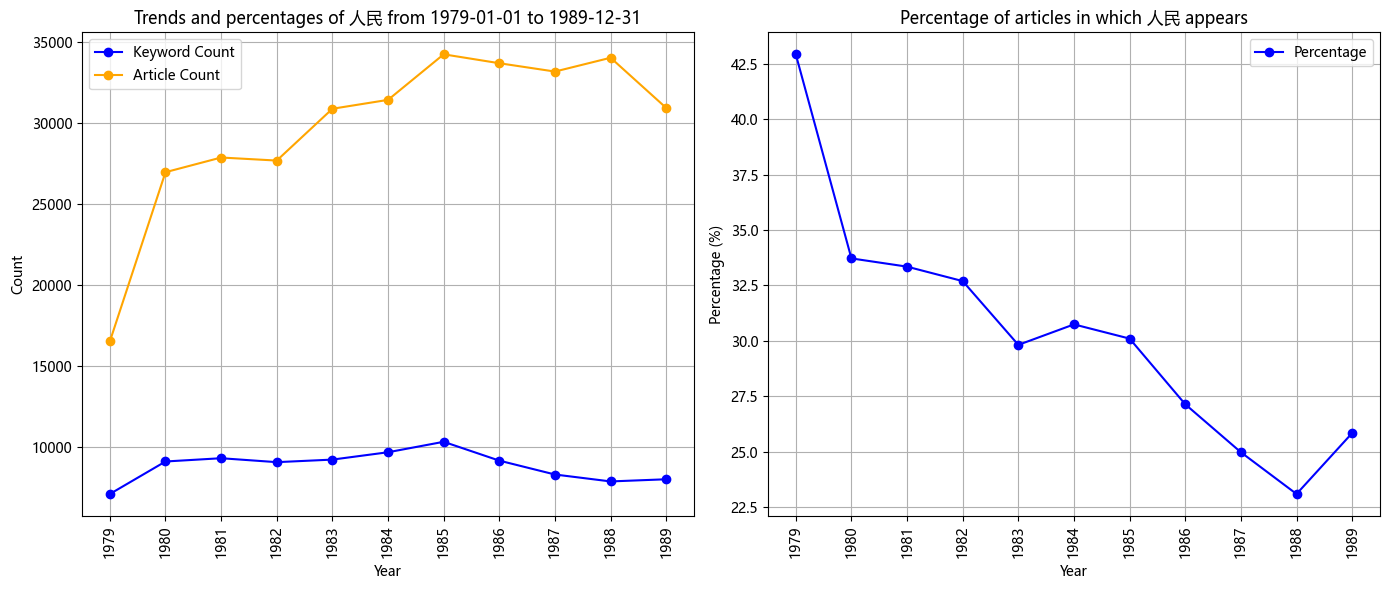

In [4]:
# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# First plot: Keyword Count and Article Count
axs[0].plot(merged_df['Year'], merged_df['Keyword Count'], marker='o', label='Keyword Count', color='blue')
axs[0].plot(merged_df['Year'], merged_df['Article Count'], marker='o', label='Article Count', color='orange')

# Adding titles and labels for the first plot
axs[0].set_title(f'Trends and percentages of {keyword} from {time_from} to {time_to}')
axs[0].set_xlabel('Year')
axs[0].set_ylabel('Count')
axs[0].set_xticks(merged_df['Year'])  # Set x-ticks to be the years
axs[0].set_xticklabels(merged_df['Year'], rotation=90)  # Rotate x-labels
axs[0].grid()
axs[0].legend()

# Second plot: Percentage
axs[1].plot(merged_df['Year'], merged_df['Percentage'], marker='o', label='Percentage', color='blue')

# Adding titles and labels for the second plot
axs[1].set_title(f'Percentage of articles in which {keyword} appears')
axs[1].set_xlabel('Year')
axs[1].set_ylabel('Percentage (%)')
axs[1].set_xticks(merged_df['Year'])  # Set x-ticks to be the years
axs[1].set_xticklabels(merged_df['Year'], rotation=90)  # Rotate x-labels
axs[1].grid()
axs[1].legend()

# Adjust layout
plt.tight_layout()

# save image
# use f-string and add the search terms to the file name
plt.savefig(fr'./out/trends_and_percentages_of{keyword}_{time_from}_{time_to}_plot.png', bbox_inches='tight')


# Show the plots
plt.show()

## Month not year

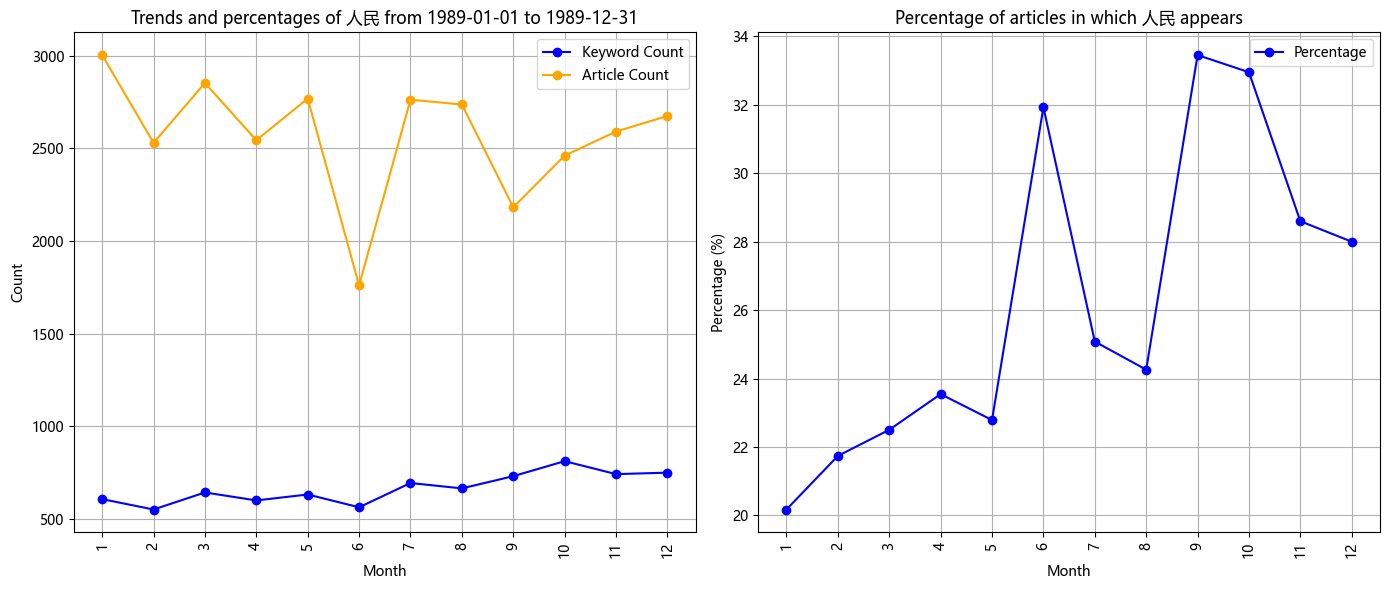

In [5]:
import sqlite3
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams["font.family"] = "Microsoft YaHei"  # husk på mac skal man bruge  'Heiti TC'

conn = sqlite3.connect('Rmrb_all_years.db')
c = conn.cursor()


# Extract articles with keyword in time period
keyword = '人民'
time_from = '1989-01-01'
time_to = '1989-12-31'


# use f-strings and add keyword, time from, and time to 
c.execute(f"SELECT * FROM rmrb WHERE (date > '{time_from}') AND (date < '{time_to}') ORDER BY date")
df = pd.DataFrame(c.fetchall())

# rename columns
df = df.loc[:, 2:].rename(columns={2:'Date', 3:'Section', 4:'Heading', 5:'Content', 6:'Page'})

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])


# Extract the month from the 'Date' column
df['Month'] = df['Date'].dt.month

# Group by the 'Month' column and count the number of rows for each month
monthly_counts_df = df.groupby('Month').size().reset_index(name='Article Count')

# Print the result
#print(yearly_counts_df)

#######################################
#######################################
# Filter content with the keyword 
df['Contains_Keyword'] = df['Content'].str.contains(keyword)
#######################################
########################################

# Group by year and sum the boolean mask to count occurrences
monthly_keyword_counts_df = df.groupby('Month')['Contains_Keyword'].sum().reset_index(name='Keyword Count')

# Print the result
#print(yearly_keyword_counts)

# Merge the two DataFrames on 'Year'
merged_df = pd.merge(monthly_keyword_counts_df, monthly_counts_df, on='Month')

# Divide to get percentage
merged_df['Percentage'] = merged_df['Keyword Count'] / merged_df['Article Count'] * 100

# print the result
#print(merged_df)

# save term frequency
merged_df.to_csv(fr'./out/trend_{keyword}_{time_from}_{time_to}.csv', index=False)




#####################################


# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# First plot: Keyword Count and Article Count
axs[0].plot(merged_df['Month'], merged_df['Keyword Count'], marker='o', label='Keyword Count', color='blue')
axs[0].plot(merged_df['Month'], merged_df['Article Count'], marker='o', label='Article Count', color='orange')

# Adding titles and labels for the first plot
axs[0].set_title(f'Trends and percentages of {keyword} from {time_from} to {time_to}')
axs[0].set_xlabel('Month')
axs[0].set_ylabel('Count')
axs[0].set_xticks(merged_df['Month'])  # Set x-ticks to be the years
axs[0].set_xticklabels(merged_df['Month'], rotation=90)  # Rotate x-labels
axs[0].grid()
axs[0].legend()

# Second plot: Percentage
axs[1].plot(merged_df['Month'], merged_df['Percentage'], marker='o', label='Percentage', color='blue')

# Adding titles and labels for the second plot
axs[1].set_title(f'Percentage of articles in which {keyword} appears')
axs[1].set_xlabel('Month')
axs[1].set_ylabel('Percentage (%)')
axs[1].set_xticks(merged_df['Month'])  # Set x-ticks to be the years
axs[1].set_xticklabels(merged_df['Month'], rotation=90)  # Rotate x-labels
axs[1].grid()
axs[1].legend()

# Adjust layout
plt.tight_layout()

# save image
# use f-string and add the search terms to the file name
plt.savefig(fr'./out/trends_and_percentages_of{keyword}_{time_from}_{time_to}_plot.png', bbox_inches='tight')


# Show the plots
plt.show()